## Task 4

In [35]:
import Consumer as cs
import Government as gv

from types import SimpleNamespace
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Task 4.1 and 4.2 - Implementing tax_revenue and considering five product taxes

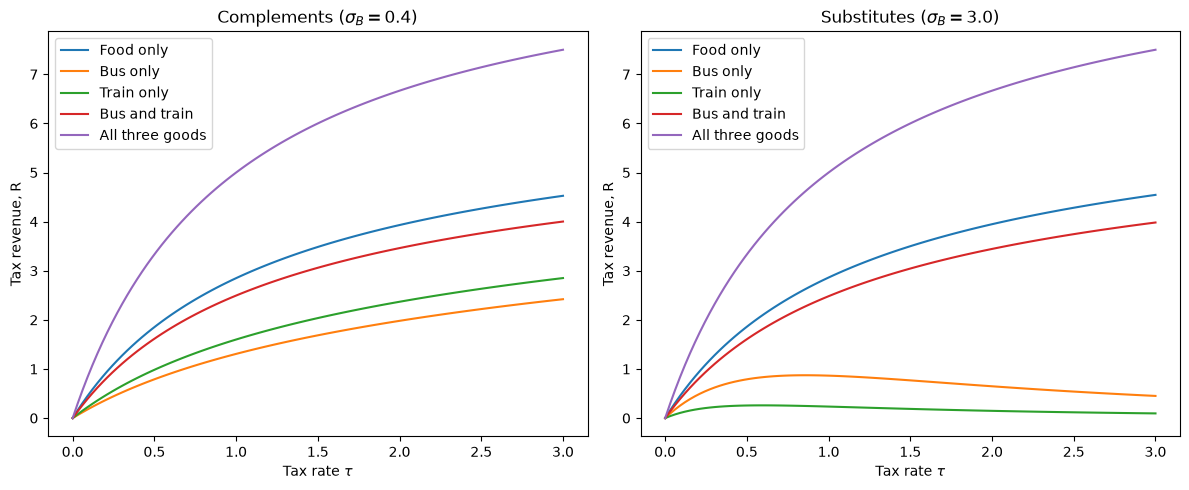

In [36]:
models = {
    'Complements ($\\sigma_B=0.4$)': gv.GovernmentClass(),
    'Substitutes ($\\sigma_B=3.0$)': gv.GovernmentClass(par={'sigma_B':3.0}),
}

instruments = {
    'Food only': (1,),
    'Bus only': (2,),
    'Train only': (3,),
    'Bus and train': (2,3),
    'All three goods': (1,2,3),
}

tau_vec = np.linspace(0,3,100)

fig,axes = plt.subplots(1,2,figsize=(12,5))

for ax,(calib_name,model) in zip(axes,models.items()):
    for label,goods in instruments.items():
        R_vec = np.empty(tau_vec.size)
        for i,tau in enumerate(tau_vec):
            R,u = model.revenue_and_utility(tau,goods=goods)
            R_vec[i] = R
        ax.plot(tau_vec,R_vec,label=label)
    ax.set_title(calib_name)
    ax.set_xlabel(r'Tax rate $\tau$')
    ax.set_ylabel('Tax revenue, R')
    ax.legend()

fig.tight_layout()
plt.show()

## Task 4.3 - Finding the revenue maximizing rate and the largest possible revenue where there is a top

In [37]:
models = {
    'Complements': gv.GovernmentClass(),
    'Substitutes': gv.GovernmentClass(par={'sigma_B':3.0}),
}
instruments = {
    'Food only': (1,),
    'Bus only': (2,),
    'Train only': (3,),
    'Bus and train': (2,3),
    'All three goods': (1,2,3),
}

rows = []
for label, goods in instruments.items():
    row = {'Instrument': label}
    for calib_name, model in models.items():
        tau_star, R_star = model.max_revenue(goods=goods, tau_max=3.0, N=3001)
        if tau_star == 3.0:
            row[f'{calib_name} Tax rate'] = "Keeps Rising"
            row[f'{calib_name} Revenue']   = "Keeps rising"
        else:
            row[f'{calib_name} Tax rate'] = f"{tau_star:.3f}"
            row[f'{calib_name} Revenue']   = f"{R_star:.3f}"
    rows.append(row)

df = pd.DataFrame(rows).set_index('Instrument')
df.round(3)

,Complements Tax rate,Complements Revenue,Substitutes Tax rate,Substitutes Revenue
Instrument,,,,
Food only,Keeps Rising,Keeps rising,Keeps Rising,Keeps rising
Bus only,Keeps Rising,Keeps rising,0.856,0.872
Train only,Keeps Rising,Keeps rising,0.593,0.259
Bus and train,Keeps Rising,Keeps rising,Keeps Rising,Keeps rising
All three goods,Keeps Rising,Keeps rising,Keeps Rising,Keeps rising


Table 1 shows the revenue-maximizing rate τ* and revenue R* for all five instruments in both calibrations, over τ ∈ [0,3]. "Keeps rising" means the grid search hit the edge of the search interval, i.e. revenue is still increasing rather than having turned over.
<br>
<br>
In the Complements calibration, all five instruments keep rising: since bus/train (σ_B=0.4) and food/travel (σ_A=0.8) are complements, the consumer can't escape a tax by substituting away, so revenue never has an interior top.
<br>
<br>
In the Substitutes calibration (σ_B=3.0), the same holds — except for Bus only and Train only. Here the consumer can flee to the untaxed good, so quantity eventually collapses faster than price rises, giving each curve a genuine top: Bus only peaks at τ*≈0.856 (R*≈0.872), Train only at τ*≈0.593 (R*≈0.259).
<br>
<br>
Answer: the most a tax on train tickets alone can ever raise, in the substitutes calibration, is R* ≈ 0.259 (about 2.6% of income), at τ* ≈ 0.593. Beyond that rate, further increases lower revenue as consumers switch to the bus.

## Task 4.4 - Plot consumer's utility against revenue raised

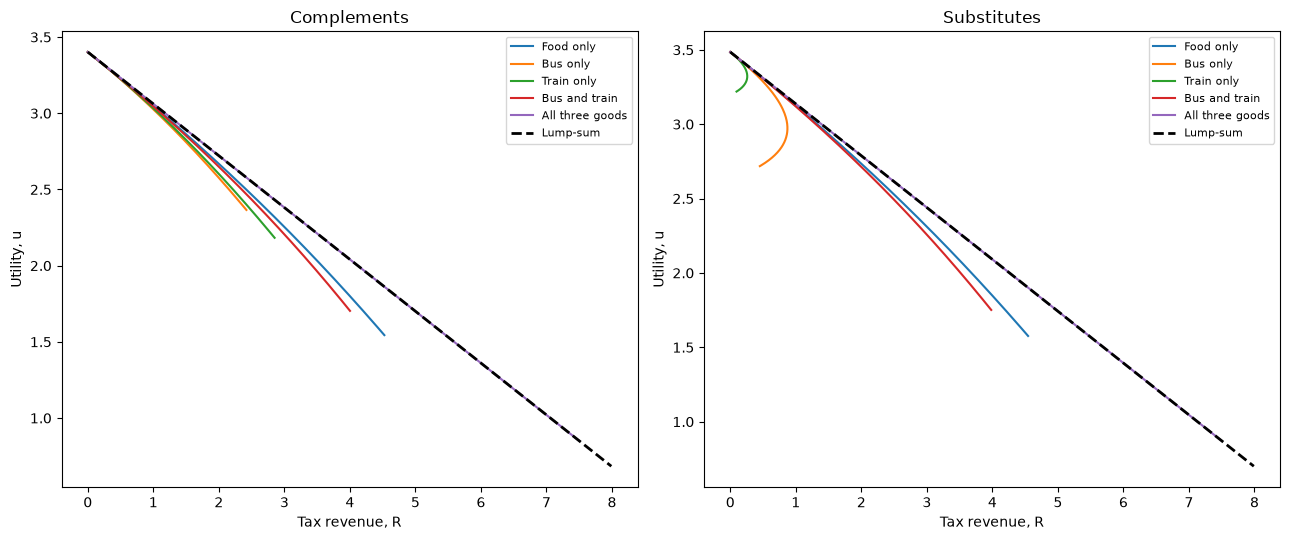

In [38]:
tau_vec = np.linspace(0,3,150)
T_vec = np.linspace(0,7.99,150)   # T can't reach I_pre=10 exactly, or income hits zero

fig,axes = plt.subplots(1,2,figsize=(13,5.5))

for ax,(calib_name,model) in zip(axes,models.items()):
    for label,goods in instruments.items():
        R_vec = np.empty(tau_vec.size); u_vec = np.empty(tau_vec.size)
        for i,t in enumerate(tau_vec):
            R_vec[i],u_vec[i] = model.revenue_and_utility(t,goods=goods)
        ax.plot(R_vec,u_vec,label=label)

    R_T = np.empty(T_vec.size); u_T = np.empty(T_vec.size)
    for i,T in enumerate(T_vec):
        R_T[i],u_T[i] = model.revenue_and_utility_lump_sum(T)
    ax.plot(R_T,u_T,'k--',linewidth=2,label='Lump-sum')

    ax.set_title(calib_name)
    ax.set_xlabel('Tax revenue, R')
    ax.set_ylabel('Utility, u')
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

The lump-sum tax and a uniform tax on all three goods are tied for cheapest at every revenue level, since taxing everything at the same rate just shrinks the real budget without changing relative prices — equivalent to a lump-sum tax with zero distortion. Taxing a single travel good (bus only or train only) is consistently the most expensive, since the consumer escapes into the untaxed alternative while revenue stays low.
<br>
<br>
This ranking depends on the calibration, but only in the middle. The extremes hold regardless of σ_B: lump-sum/all-three-goods stays cheapest, single travel-good taxation stays most expensive. What flips is "Food only" versus "Bus and train": under Complements (σ_B=0.4), taxing bus and train together is cheaper, since they can't substitute for each other anyway; under Substitutes (σ_B=3.0), taxing food alone becomes cheaper, since taxing bus and train jointly removes the consumer's only escape route between the two. Overall, a tax's cost depends less on which good is taxed than on how much substitution is available around it.

## Task 4.5 - Let the government need R = 0.20

In [39]:
R_target = 0.20

for calib_name, model in models.items():
    rows = []
    for label, goods in instruments.items():
        # use the revenue-maximizing rate as the upper end of the bracket,
        # so we always search the rising (least distortionary) branch
        tau_peak,R_peak = model.max_revenue(goods=goods, tau_max=5.0, N=2001)
        tau_star = model.find_tax_rate(R_target, goods=goods, bracket=(1e-10,tau_peak))
        if np.isnan(tau_star):
            rows.append({'Instrument':label,'Tax rate':np.nan,'Utility':np.nan})
        else:
            R_check,u = model.revenue_and_utility(tau_star, goods=goods)
            rows.append({'Instrument':label,'Tax rate':tau_star,'Utility':u})

    # lump-sum: R = T always, no root-finder needed
    T = R_target
    R_ls,u_ls = model.revenue_and_utility_lump_sum(T)
    rows.append({'Instrument':'Lump-sum','Tax rate':T,'Utility':u_ls})

    df = pd.DataFrame(rows).set_index('Instrument').sort_values('Utility',ascending=False)
    print(calib_name)
    display(
        df.style
            .format('{:.3f}')
            .set_properties(**{'padding': '4px 40px'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '4px 40px')]}
            ])
    )

Complements


,Tax rate,Utility
Instrument,,
Lump-sum,0.200,3.334
All three goods,0.020,3.334
Food only,0.039,3.333
Bus and train,0.045,3.333
Train only,0.081,3.333
Bus only,0.104,3.332


Substitutes


,Tax rate,Utility
Instrument,,
Lump-sum,0.200,3.415
All three goods,0.020,3.415
Food only,0.038,3.415
Bus and train,0.045,3.415
Bus only,0.070,3.412
Train only,0.236,3.396


In both calibrations, lump-sum and taxing all three goods are tied for cheapest at R=0.20, followed closely by Food only, Bus and train, and Bus only, with only small differences between them since a modest revenue target barely distorts behavior. 
<br>
<br>
Train only breaks this pattern, but only in the Substitutes calibration, where it ends up clearly last: because bus and train are close substitutes there, consumers escape a train tax by switching to the bus, so reaching R=0.20 requires a much higher rate (τ≈0.236 vs. τ≈0.081 under Complements) and leaves the consumer noticeably worse off than under any other instrument. This matches the section 4.3 finding that a train tax alone can never raise more than about 0.259 in this calibration, meaning R=0.20 already sits on the steep, inefficient part of that curve. 
<br>
<br>
Under Complements, by contrast, there's no close substitute to escape to, so taxing the train costs about the same as any other narrow-based tax.